In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
df = pd.read_csv('/content/comments.csv')

print(df.shape)

df.info()

df.describe()

(7488, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   7488 non-null   int64 
 1   comment              7488 non-null   object
 2   User  id             7488 non-null   int64 
 3   Photo id             7488 non-null   int64 
 4   created Timestamp    7488 non-null   object
 5   posted date          7488 non-null   object
 6   emoji used           7488 non-null   object
 7   Hashtags used count  7488 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 468.1+ KB


,id,User id,Photo id,Hashtags used count
count,7488.000000,7488.000000,7488.000000,7488.000000
mean,3744.500000,48.949386,129.099225,2.416667
std,2161.743741,28.354045,73.776439,1.705905
min,1.000000,2.000000,1.000000,0.000000
25%,1872.750000,24.000000,65.000000,1.000000
50%,3744.500000,48.000000,130.000000,2.000000
75%,5616.250000,72.000000,193.000000,3.250000
max,7488.000000,100.000000,257.000000,6.000000


In [4]:
df.isnull().sum()

,0
id,0
comment,0
User id,0
Photo id,0
created Timestamp,0
posted date,0
emoji used,0
Hashtags used count,0


In [5]:
df['created Timestamp'] = pd.to_datetime(
    df['created Timestamp'],
    format='%d-%m-%Y %H:%M'
)

df.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,2023-04-13 08:04:00,April 14,yes,1
1,2,quae ea ducimus,3,1,2023-04-13 08:04:00,April 14,no,2
2,3,alias a voluptatum,5,1,2023-04-13 08:04:00,April 14,no,4
3,4,facere suscipit sunt,14,1,2023-04-13 08:04:00,April 14,yes,2
4,5,totam eligendi quaerat,17,1,2023-04-13 08:04:00,April 14,yes,1


In [6]:
df['Hour'] = df['created Timestamp'].dt.hour
df['Day'] = df['created Timestamp'].dt.day_name()
df['Month'] = df['created Timestamp'].dt.month_name()

df.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count,Hour,Day,Month
0,1,unde at dolorem,2,1,2023-04-13 08:04:00,April 14,yes,1,8,Thursday,April
1,2,quae ea ducimus,3,1,2023-04-13 08:04:00,April 14,no,2,8,Thursday,April
2,3,alias a voluptatum,5,1,2023-04-13 08:04:00,April 14,no,4,8,Thursday,April
3,4,facere suscipit sunt,14,1,2023-04-13 08:04:00,April 14,yes,2,8,Thursday,April
4,5,totam eligendi quaerat,17,1,2023-04-13 08:04:00,April 14,yes,1,8,Thursday,April


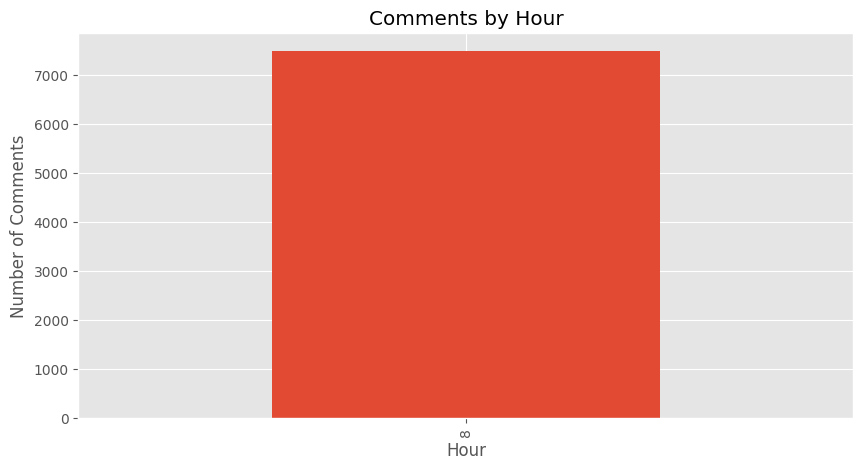

In [7]:
hourly_comments = df.groupby('Hour').size()

plt.figure(figsize=(10,5))
hourly_comments.plot(kind='bar')

plt.title("Comments by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Comments")
plt.show()

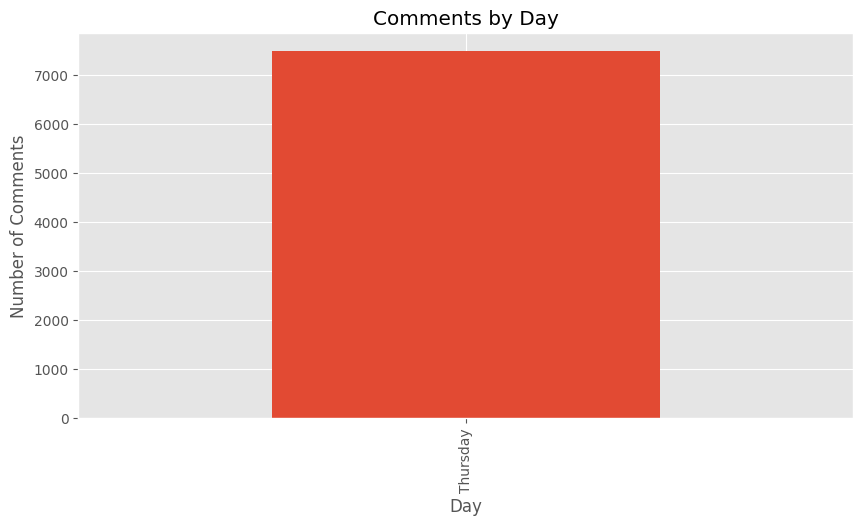

In [8]:
day_comments = df.groupby('Day').size()

plt.figure(figsize=(10,5))
day_comments.plot(kind='bar')

plt.title("Comments by Day")
plt.xlabel("Day")
plt.ylabel("Number of Comments")
plt.show()

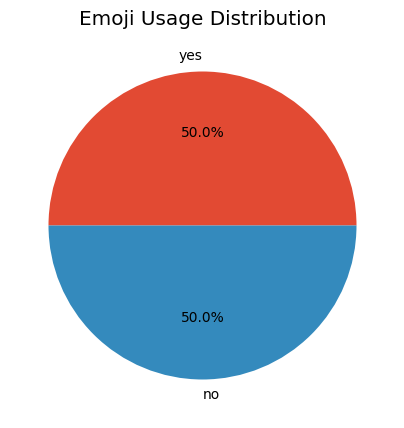

In [9]:
emoji_counts = df['emoji used'].value_counts()

plt.figure(figsize=(5,5))
emoji_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title("Emoji Usage Distribution")
plt.show()

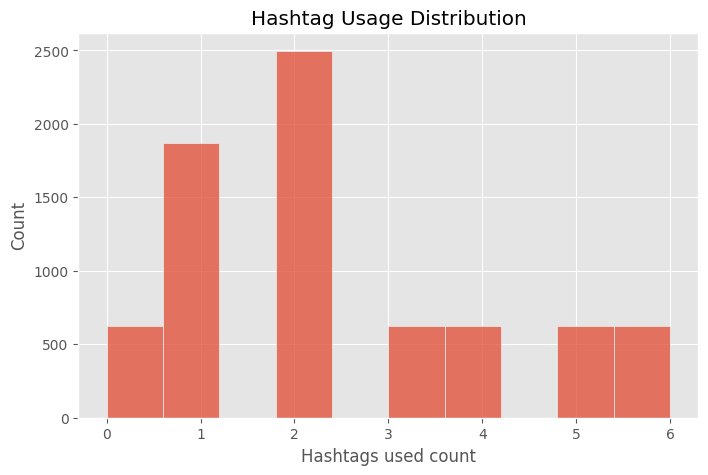

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Hashtags used count'],
    bins=10
)

plt.title("Hashtag Usage Distribution")
plt.show()

In [11]:
avg_hashtags = df['Hashtags used count'].mean()

print("Average Hashtags Used:", round(avg_hashtags,2))

Average Hashtags Used: 2.42


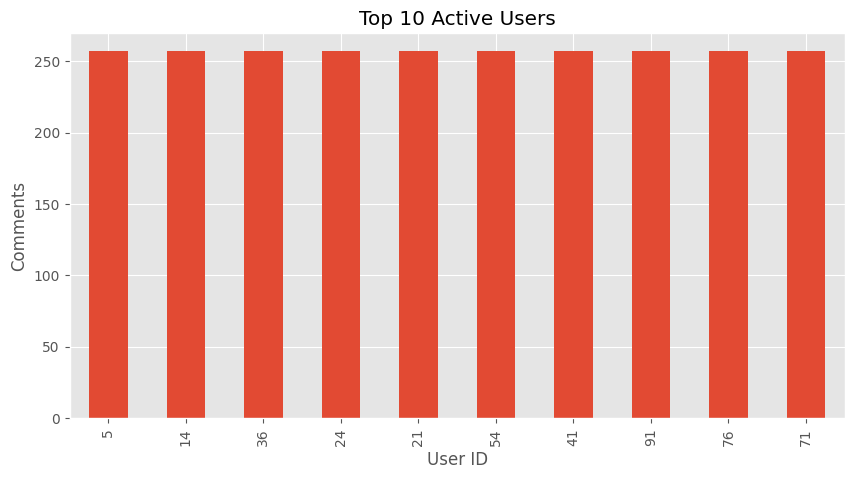

In [12]:
top_users = df['User  id'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_users.plot(kind='bar')

plt.title("Top 10 Active Users")
plt.xlabel("User ID")
plt.ylabel("Comments")
plt.show()

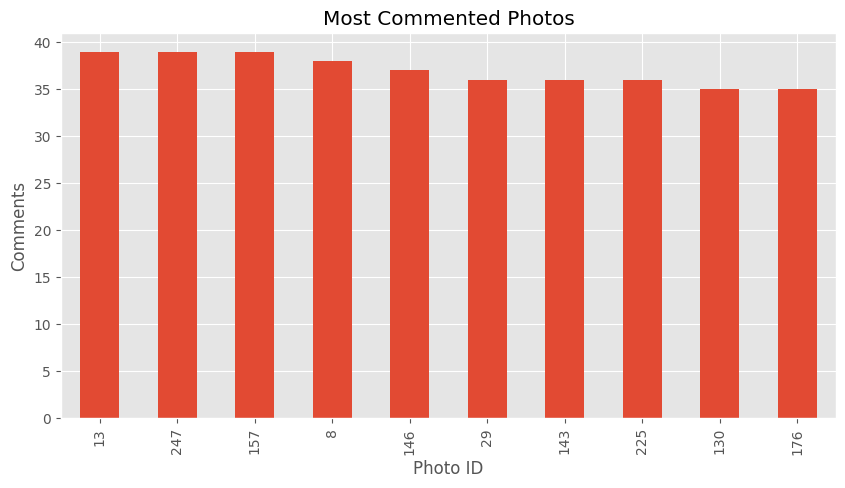

In [13]:
top_photos = df['Photo id'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_photos.plot(kind='bar')

plt.title("Most Commented Photos")
plt.xlabel("Photo ID")
plt.ylabel("Comments")
plt.show()

In [14]:
print("Key Insights")
print("- Peak activity hours can be identified from hourly analysis.")
print("- Emoji usage indicates user engagement style.")
print("- Photos with highest comments are the most engaging.")
print("- Active users contribute significantly to discussions.")
print("- Hashtag usage affects visibility and interaction.")

Key Insights
- Peak activity hours can be identified from hourly analysis.
- Emoji usage indicates user engagement style.
- Photos with highest comments are the most engaging.
- Active users contribute significantly to discussions.
- Hashtag usage affects visibility and interaction.
